# The Continuous Thought Machine – Tutorial 05: Hugging Face [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SakanaAI/continuous-thought-machines/blob/main/examples/05_huggingface.ipynb) [![arXiv](https://img.shields.io/badge/arXiv-2505.05522-b31b1b.svg)](https://arxiv.org/abs/2505.05522)

The CTM is now on Hugging Face! 🤗

Specifically, we have uploaded the image classification CTM trained on ImageNet, and the large maze solving CTM. Additionally, we have uploaded the maze datsets (in small, medium, large and extralarge variants) to make working with this task more convienient!

In this notebook, we walkthough how to load both of these models, as well as how to use the maze datasets.

## Setup

We first clone the CTM repo to access the ContinuousThoughtMachine model class, as well as a helper for labelling ImageNet images.

In [1]:
# !git clone https://github.com/SakanaAI/continuous-thought-machines.git
!git clone -b ciaran/hf https://github.com/ciaran-regan-ie/continuous-thought-machines.git

fatal: destination path 'continuous-thought-machines' already exists and is not an empty directory.


In [28]:
import sys
sys.path.append("./continuous-thought-machines")


import torch
import numpy as np
import random
from PIL import Image
from torchvision import transforms
import urllib
import matplotlib.pyplot as plt
from tqdm import tqdm

from models.ctm import ContinuousThoughtMachine as CTM
from tasks.image_classification.imagenet_classes import IMAGENET2012_CLASSES
from utils.losses import maze_loss 

In [ ]:
def set_seed(seed=42, deterministic=True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cudnn.benchmark = False

In [ ]:
set_seed(42)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Loading a Pretrained Model

To load the image classfication CTM we can simply call `from_pretrained` on the CTM class.

In [39]:
model = CTM.from_pretrained("ciaran-regan-ie/imagenet-ctm")
model = model.to(device)
model.eval();

Using neuron select type: random-pairing
Synch representation size action: 2048
Synch representation size out: 8196


Lets test the model by running inference on it. We download an image and convert it to a PyTorch Tensor.

In [7]:

url = "https://www.seahorseaquariums.com/image/cache/catalog/Categories%20-%20Freshewater/Coldwater%20Fish/Fantails/Fantail%20Goldfish-2000x2000.jpg"
filename = "goldfish.jpg"
target = 1  # Goldfish
urllib.request.urlretrieve(url, filename)
image = Image.open(filename).convert("RGB")

# Preprocess the image
dataset_mean = [0.485, 0.456, 0.406]
dataset_std = [0.229, 0.224, 0.225]
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean, std=dataset_std)
])

input_tensor = transform(image).unsqueeze(0).to(device)

Run a forward pass with the CTM. For simplicity, we take the prediction at the last internal tick as the final prediction. Alternatively we could use the prediction at the models most certain internal tick. See [tutorial 01: MNIST](https://github.com/SakanaAI/continuous-thought-machines/blob/main/examples/01_mnist.ipynb) for more details.

In [ ]:
with torch.no_grad():
    predictions, _, _ = model(input_tensor)

# Get predictions
prediction_last = predictions[0, :, -1].argmax(dim=0)
IMAGENET_CLASS_LIST = list(IMAGENET2012_CLASSES.values())

print(f"Target Class: {target} = {IMAGENET_CLASS_LIST[target]}")
print(f"Predicted Class (final): {prediction_last.item()} = {IMAGENET_CLASS_LIST[prediction_last.item()]}")

Target Class: 1 = goldfish, Carassius auratus
Predicted Class (final): 1 = goldfish, Carassius auratus


The pretrained CTM correctly classifies the image as a goldfish! 🐠

## Maze Datasets

We will now showcase how to use the maze datasets from Hugging Face, as well as loading a pretrained maze solving CTM.

We use [Hugging Face datasets](https://huggingface.co/docs/datasets/en/index) to load the maze data.

## Dataset Structure

Each dataset contains train and test splits with the following fields:

- **`image`**: A PIL Image in RGB format representing the maze
  - **Red pixel** (255, 0, 0): Start position
  - **Green pixel** (0, 255, 0): End/goal position  
  - **Blue pixel** (0, 0, 255): Valid path (walkable areas)
  - **Black/White**: Walls and obstacles

- **`solution_path`**: A list of integers representing the sequence of moves to solve the maze
  - `0` = Move Up ↑
  - `1` = Move Down ↓
  - `2` = Move Left ←
  - `3` = Move Right →
  - `4` = Wait/Padding (used when solution is shorter than fixed length)

## Dataset Sizes

| Variant | Image Size | Solution Path Length |
|---------|------------|---------------------|
| small | 15×15 | 50 |
| medium | 19×19| 50 |
| large | 39×39 | 100 |
| extralarge | 99×99 | 100 |

When converted to tensors for training, images become shape `(3, H, W)` after applying `.permute(2, 0, 1)`.

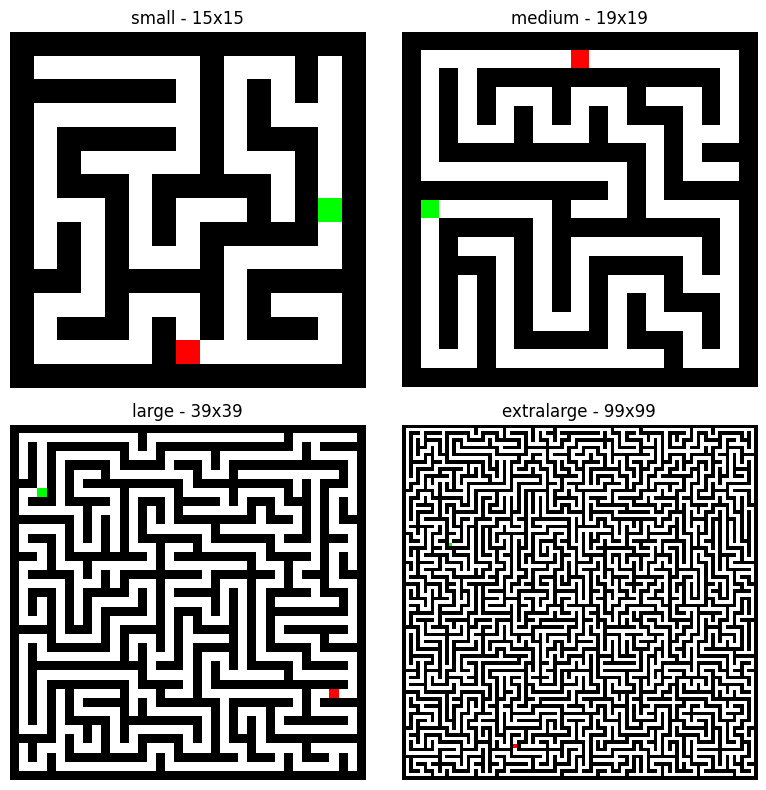

In [ ]:
from datasets import load_dataset

# Load all size datasets
sizes = ["small", "medium", "large", "extralarge"]
datasets = {}

for size in sizes:
    repo_name = f"ciaran-regan-ie/mazes-{size}"
    datasets[size] = load_dataset(repo_name)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for idx, size in enumerate(sizes):
    
    # Get first example from train set
    example = datasets[size]['train'][0]
    image = example['image']  
    axes[idx].imshow(image)
        
    axes[idx].set_title(f"{size} - {image.size[0]}x{image.size[1]}")
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig("maze_sizes_comparison.png", dpi=50, bbox_inches='tight')
plt.show()

Now lets test the pretrain maze solving CTM!

In [38]:
# Load the model
model = CTM.from_pretrained(f"ciaran-regan-ie/mazes-large-ctm")
model = model.to(device)
model.eval();

Using neuron select type: first-last
Synch representation size action: 528
Synch representation size out: 2080


In [20]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    """Custom collate function for DataLoader"""
    images = []
    solutions = []
    
    for item in batch:
        # Convert image to tensor
        image_array = np.array(item['image']).astype(np.float32) / 255.0
        image_tensor = torch.from_numpy(image_array).permute(2, 0, 1)            
        images.append(image_tensor)
        solutions.append(torch.tensor(item['solution_path'], dtype=torch.long))
    
    images = torch.stack(images)
    solutions = torch.stack(solutions)
    
    return images, solutions

test_loader = DataLoader(
    datasets["large"]['test'],
    batch_size=64,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

In [31]:
def evaluate_batch(model, dataloader, device, max_batches=None):
    """Evaluate model on batches of data"""
    model.eval()
    
    all_targets = []
    all_predictions_most_certain = []
    all_losses = []

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(tqdm(dataloader, desc="Evaluating")):
            if max_batches and batch_idx >= max_batches:
                break
                
            images = images.to(device)
            targets = targets.to(device)

            # Run inference
            predictions_raw, certainties, _ = model(images)
            predictions = predictions_raw.reshape(predictions_raw.size(0), -1, 5, predictions_raw.size(-1))
            
            # Calculate loss and get most certain predictions
            loss, where_most_certain, _ = maze_loss(predictions, certainties, targets, use_most_certain=True)
            all_losses.append(loss.item())
            
            # Get predictions at most certain time step
            pred_at_certain = predictions.argmax(2)[
                torch.arange(predictions.size(0), device=predictions.device), 
                :, 
                where_most_certain
            ]
            
            all_targets.append(targets.cpu().numpy())
            all_predictions_most_certain.append(pred_at_certain.cpu().numpy())

        # Concatenate all batches
        all_targets = np.concatenate(all_targets)
        all_predictions_most_certain = np.concatenate(all_predictions_most_certain)
        
        # Calculate metrics
        step_accuracy = (all_targets == all_predictions_most_certain).mean()
        maze_solve_rate = (all_targets == all_predictions_most_certain).all(axis=1).mean()
        avg_loss = np.mean(all_losses)

    return step_accuracy, maze_solve_rate, avg_loss

In [33]:
step_accuracy, maze_solve_rate, avg_loss = evaluate_batch(model, test_loader, device, max_batches=20)


Evaluating:  25%|██▌       | 20/79 [00:02<00:08,  7.10it/s]


In [34]:
print(f"Step Accuracy: {step_accuracy*100:.2f}%")
print(f"Maze Solve Rate: {maze_solve_rate*100:.2f}%")
print(f"Average Loss: {avg_loss:.4f}")

Step Accuracy: 99.15%
Maze Solve Rate: 94.38%
Average Loss: 0.0289
